In [25]:
import numpy as np
import matplotlib.pyplot as plt


In [26]:
temp=np.array([10,15,20,25,30,35,50])
sales = np.array([140,120,100,80,60,40,20])


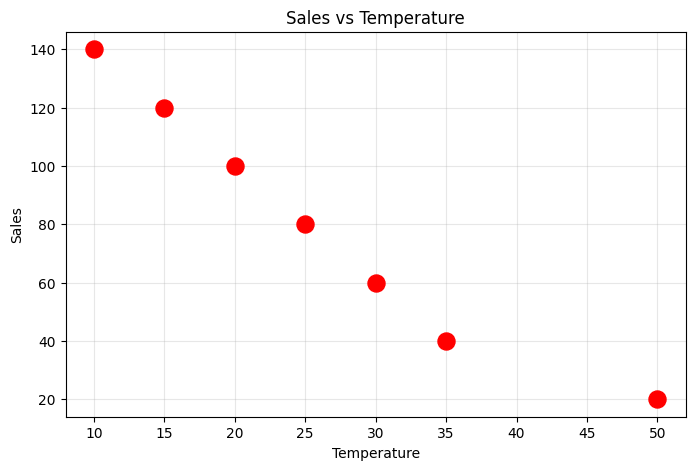

In [27]:
plt.figure(figsize=(8,5))
plt.scatter(temp,sales,color='red',s=150,zorder=3)
plt.xlabel("Temperature")
plt.ylabel("Sales")
plt.grid(True,alpha =0.3)
plt.title("Sales vs Temperature")
plt.show()


In [28]:
w_guess1 =0
b_guess1 =0
pred_guess1 =w_guess1*temp +b_guess1
print(pred_guess1)


[0 0 0 0 0 0 0]


In [29]:
w_guess2 =-2
b_guess2 =100
pred_guess2 =w_guess2*temp +b_guess2
print(pred_guess2)
msme_guess2 = np.mean((pred_guess2-sales)**2)
print(msme_guess2)

[80 70 60 50 40 30  0]
1357.142857142857


In [30]:
w_guess3 =-4
b_guess3 =180
pred_guess3 =w_guess3*temp +b_guess3
print(pred_guess3)
msme_guess3 = np.mean((pred_guess3-sales)**2)
print(msme_guess3)



[140 120 100  80  60  40 -20]
228.57142857142858


In [31]:
# Error (Loss)
total_square_error =0
for i in range(len(temp)):
  pred = -2 * temp[i] +100
 # print(pred)
  error = pred - sales[i]
  #print(error)
  sqr_error = error ** 2
  total_square_error = total_square_error + sqr_error
#  print(total_square_error)

mse = total_square_error/len(temp)
print(mse)







1357.142857142857


In [32]:
# Gradient Descent
X_norm = (temp -temp.mean())/temp.std()
Y_norm = (sales -sales.mean())/sales.std()
print(X_norm)
print(Y_norm)
w =0.0
b= 0.0
lr =0.1
epochs =50
losses=[]


[-1.31914047 -0.91766294 -0.5161854  -0.11470787  0.28676967  0.6882472
  1.8926798 ]
[ 1.5  1.   0.5  0.  -0.5 -1.  -1.5]


In [40]:
# Model training
for epoch in range(epochs):
  y_pred = w*X_norm +b
  error = y_pred - Y_norm
  mse = np.mean(error**2)
  losses.append(mse)
  n =len(X_norm)
  dw = (2/n) * np.sum(error * X_norm)
  print(dw)
  db = (2/n) * np.sum(error)
  print(db)
  w = w - lr * dw
  print(w)
  b = b - lr * db

2.783181153117756e-05
-2.220446049250313e-16
-0.975005736225275
2.2265449225043555e-05
-2.0618427600181477e-16
-0.9750079627701975
1.7812359379888927e-05
-1.586032892321652e-16
-0.9750097440061355
1.424988750407609e-05
-6.344131569286608e-17
-0.9750111689948859
1.1399910003159367e-05
-9.516197353929913e-17
-0.9750123089858862
9.119928002533837e-06
-6.344131569286608e-17
-0.9750132209786865
7.295942402008038e-06
-6.344131569286608e-17
-0.9750139505729267
5.836753921581053e-06
-6.344131569286608e-17
-0.9750145342483189
4.669403137290219e-06
-3.172065784643304e-17
-0.9750150011886326
3.7355225097941106e-06
-3.172065784643304e-17
-0.9750153747408836
2.9884180077528148e-06
0.0
-0.9750156735826844
2.3907344061895633e-06
-7.93016446160826e-17
-0.975015912656125
1.9125875249897154e-06
-3.172065784643304e-17
-0.9750161039148775
1.5300700198902663e-06
4.7580986769649563e-17
-0.9750162569218794
1.2240560161659784e-06
-6.344131569286608e-17
-0.9750163793274811
9.792448128566531e-07
1.1102230246251

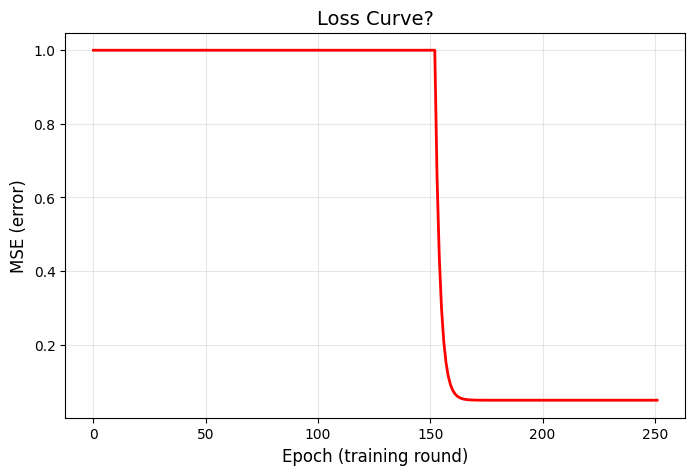

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(losses, color="red", linewidth=2)
plt.title("Loss Curve?", fontsize=14)
plt.xlabel("Epoch (training round)", fontsize=12)
plt.ylabel("MSE (error)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

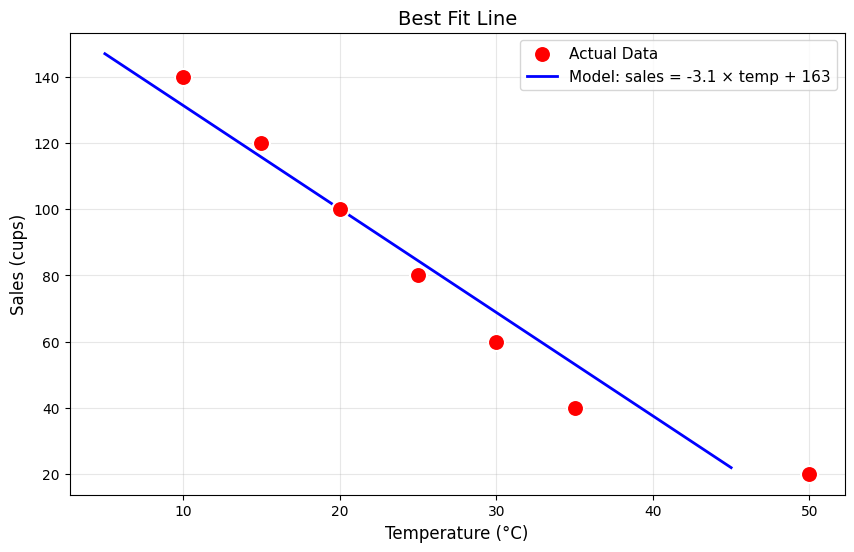

In [46]:
# Cell 8: DENORMALIZE

w_real = w * sales.std() / temp.std()
b_real = sales.mean() + b * sales.std() - w_real * temp.mean()
plt.figure(figsize=(10, 6))
plt.scatter(temp, sales, color="red", s=150, zorder=5, edgecolors="white", linewidth=1.5, label="Actual Data")
line_temps = np.linspace(5, 45, 100)
line_sales = w_real * line_temps + b_real
plt.plot(line_temps, line_sales, color="blue", linewidth=2, label=f"Model: sales = {w_real:.1f} × temp + {b_real:.0f}")
plt.title("Best Fit Line", fontsize=14)
plt.xlabel("Temperature (°C)", fontsize=12)
plt.ylabel("Sales (cups)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Cell 11: EVALUATION
y_pred_real = w_real * temperature + b_real
ss_res = np.sum((sales - y_pred_real) ** 2)
ss_tot = np.sum((sales - sales.mean()) ** 2)
r2 = 1 - (ss_res / ss_tot)
mae = np.mean(np.abs(sales - y_pred_real))





In [48]:
# Cell 12: SKLEARN


from sklearn.linear_model import LinearRegression
X_sk = temp.reshape(-1, 1)
model = LinearRegression()
model.fit(X_sk, sales)
print(f"  w (slope): {model.coef_[0]:.2f}")
print(f"  b (intercept): {model.intercept_:.2f}")
print(f"\n  Formula: sales = {model.coef_[0]:.2f} × temp + {model.intercept_:.2f}")
# ── Compare ──
print(f"\n{'─'*45}")
print(f"{'COMPARISON':^45}")
print(f"{'─'*45}")
print(f"{'':>15} {'Scratch':>12} {'Sklearn':>12}")
print(f"{'w (slope)':>15} {w_real:>12.2f} {model.coef_[0]:>12.2f}")
print(f"{'b (intercept)':>15} {b_real:>12.2f} {model.intercept_:>12.2f}")



  w (slope): -3.13
  b (intercept): 162.76

  Formula: sales = -3.13 × temp + 162.76

─────────────────────────────────────────────
                 COMPARISON                  
─────────────────────────────────────────────
                     Scratch      Sklearn
      w (slope)        -3.13        -3.13
  b (intercept)       162.76       162.76
